# Exploratory Data Analysis — Credit Card Default Prediction

**Goal:** understand the development data before modelling — check structure and
missing values, identify data-quality issues that must be cleaned, and measure how
each feature relates to the target (`default.payment.next.month`).

**Workflow note:** cleaning decisions are *discovered* here on the raw data, then
implemented once in `preprocess.load_data()`, which is the single source of truth
reused by `train.py` and `predict.py`. This notebook is for insight only — it does
not modify or save data.

In [1]:
import sys
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from preprocess import load_data

TARGET = "default.payment.next.month"

## 1. Raw inspection — what needs cleaning?

First we load the **raw** file (no cleaning) to discover data-quality issues. This
is the discovery step; the fixes it motivates are implemented in `load_data()`.

In [2]:
df_raw = pd.read_csv("../data/raw/dev.csv")
df_raw["EDUCATION"].value_counts()

EDUCATION
2    11256
1     8455
3     3903
5      235
4       97
6       42
0       12
Name: count, dtype: int64

In [3]:
df_raw["MARRIAGE"].value_counts()

MARRIAGE
2    12806
1    10892
3      255
0       47
Name: count, dtype: int64

In [4]:
df_raw["PAY_0"].value_counts()

PAY_0
 0    11781
-1     4527
 1     3000
-2     2198
 2     2138
 3      245
 4       58
 5       18
 8       16
 6       10
 7        9
Name: count, dtype: int64

### Decision

- **EDUCATION** is documented as 1–4 but also contains undocumented codes **0, 5, 6**.
  These are sparse, so we fold them into **4 ("other")**.
- **MARRIAGE** is documented as 1–3 but contains **0**, which we fold into **3 ("other")**.
- **PAY_0…PAY_6**: the documentation defines values -1 to 9, but the data also contains
  **-2** and **0**. Because these undocumented values are frequent (not stray errors) and the
  columns are inherently **ordinal** — a higher value means a longer payment delay — we
  **keep them unchanged** and treat the columns as ordinal numeric features. We make no
  assumption about the exact meaning of -2 and 0 beyond their position on this scale;
  empirically they behave like the other non-late states.

These rules are implemented in `load_data()`. From here on we load the cleaned data
through that function rather than cleaning by hand.

## 2. Load cleaned data (via `load_data`)

In [5]:
df = load_data("../data/raw/dev.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,22777,160000.0,2,2,2,33,2,2,3,2,...,164310.0,162681.0,163005.0,15000.0,0.0,0.0,6100.0,12300.0,6100.0,0
1,9536,150000.0,2,1,2,34,1,-1,-1,-2,...,0.0,0.0,0.0,53.0,0.0,0.0,0.0,0.0,0.0,0
2,5387,10000.0,1,2,1,50,1,2,0,0,...,8067.0,8227.0,8400.0,2.0,1281.0,1134.0,294.0,305.0,1000.0,0
3,26582,220000.0,2,1,2,29,0,0,0,0,...,218513.0,131660.0,134346.0,9100.0,9000.0,7887.0,4800.0,4900.0,6000.0,1
4,4724,310000.0,2,1,2,32,1,-2,-1,0,...,326.0,-235.0,-235.0,0.0,326.0,0.0,0.0,0.0,1200.0,0


In [6]:
# Verify the cleaning: only valid category codes should remain
print("EDUCATION:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE :", sorted(df["MARRIAGE"].unique()))

EDUCATION: [1, 2, 3, 4]
MARRIAGE : [1, 2, 3]


## 3. Structure and missing values

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          24000 non-null  int64  
 1   LIMIT_BAL                   24000 non-null  float64
 2   SEX                         24000 non-null  int64  
 3   EDUCATION                   24000 non-null  int64  
 4   MARRIAGE                    24000 non-null  int64  
 5   AGE                         24000 non-null  int64  
 6   PAY_0                       24000 non-null  int64  
 7   PAY_2                       24000 non-null  int64  
 8   PAY_3                       24000 non-null  int64  
 9   PAY_4                       24000 non-null  int64  
 10  PAY_5                       24000 non-null  int64  
 11  PAY_6                       24000 non-null  int64  
 12  BILL_AMT1                   24000 non-null  float64
 13  BILL_AMT2                   240

In [8]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

**Observation:** 24,000 records, 25 columns, **no missing values** — so no imputation
is required. All columns are numeric.

## 4. Feature distributions

In [9]:
df["SEX"].value_counts()

SEX
2    14514
1     9486
Name: count, dtype: int64

In [10]:
df["EDUCATION"].value_counts()

EDUCATION
2    11256
1     8455
3     3903
4      386
Name: count, dtype: int64

In [11]:
df["MARRIAGE"].value_counts()

MARRIAGE
2    12806
1    10892
3      302
Name: count, dtype: int64

In [12]:
df["PAY_0"].value_counts()

PAY_0
 0    11781
-1     4527
 1     3000
-2     2198
 2     2138
 3      245
 4       58
 5       18
 8       16
 6       10
 7        9
Name: count, dtype: int64

**Observation:** the most common `PAY_0` state is 0, followed by
-1 and 1. The categorical features are reasonably populated except EDUCATION=4 and
MARRIAGE=3, which are small "other" buckets.

## 5. Target distribution and class imbalance

In [13]:
df[TARGET].value_counts(normalize=True).round(3)

default.payment.next.month
0    0.779
1    0.221
Name: proportion, dtype: float64

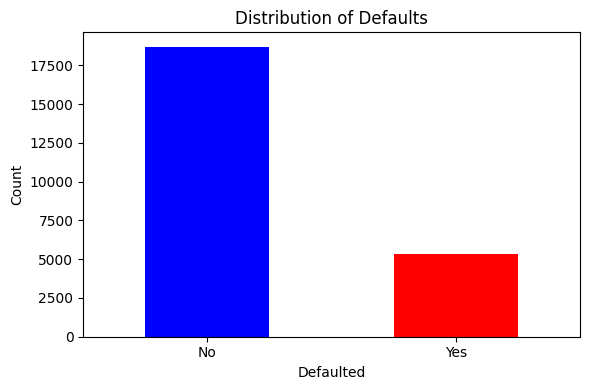

In [14]:
plt.figure(figsize=(6, 4))
df[TARGET].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Distribution of Defaults')
plt.xlabel('Defaulted')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/default_distribution.png')
plt.show()

**Observation:** about **22% of clients default** (5,309 of 24,000). The classes are
imbalanced, which is why the project is scored on **Macro F1** rather than accuracy — a
model that always predicts "no default" would reach ~78% accuracy but a poor Macro F1.

## 6. Default rate by demographic category

In [15]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(df.groupby(col)[TARGET].mean().round(3), "\n")

SEX
1    0.244
2    0.206
Name: default.payment.next.month, dtype: float64 

EDUCATION
1    0.193
2    0.238
3    0.250
4    0.073
Name: default.payment.next.month, dtype: float64 

MARRIAGE
1    0.233
2    0.210
3    0.255
Name: default.payment.next.month, dtype: float64 



**Observation:** demographic effects are weak-to-moderate. Men default slightly more
than women (24.4% vs 20.6%). Default rate rises with lower education (graduate 19.3% →
high school 25.0%); the EDUCATION=4 ("other") rate of 7.3% is unreliable as the group is
tiny (386 clients). Marital "other" (25.5%) is the highest but also small.

## 7. Which features separate the classes? (discriminative screen)

Before claiming any feature is the "strongest", we rank all features by their association
with the target. This makes the claim evidence-based rather than assumed.

In [16]:
screen = (df.drop(columns="ID")
            .corr(numeric_only=True)[TARGET]
            .drop(TARGET)
            .abs()
            .sort_values(ascending=False))
print(screen.round(3))

PAY_0        0.328
PAY_2        0.266
PAY_3        0.239
PAY_4        0.220
PAY_5        0.203
PAY_6        0.189
LIMIT_BAL    0.161
PAY_AMT1     0.073
PAY_AMT2     0.065
PAY_AMT4     0.055
PAY_AMT3     0.054
PAY_AMT6     0.053
PAY_AMT5     0.053
SEX          0.044
EDUCATION    0.032
MARRIAGE     0.023
BILL_AMT1    0.023
BILL_AMT3    0.018
BILL_AMT2    0.018
BILL_AMT4    0.014
AGE          0.013
BILL_AMT5    0.010
BILL_AMT6    0.008
Name: default.payment.next.month, dtype: float64


**Observation:** ranking features by absolute correlation with the target answers *which*
features matter, instead of assuming it. The **`PAY_*` repayment-status columns lead the
ranking, with `PAY_0` (the most recent month) highest**; influence fades for older months
(PAY_2 > PAY_3 > ... > PAY_6). `LIMIT_BAL` appears moderately, while bill and previous-payment
amounts correlate weakly. *Confirm the exact order against your printed output.* Because this
is a **linear** screen it can understate non-linear effects, so we treat it as a guide and let
the model's feature importances give the final word.

## 8. Repayment status (PAY_0) examined in detail

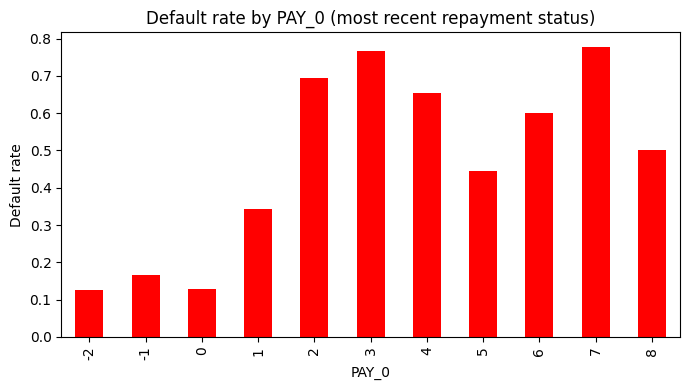

PAY_0
-2    0.127
-1    0.166
 0    0.128
 1    0.344
 2    0.694
 3    0.767
 4    0.655
 5    0.444
 6    0.600
 7    0.778
 8    0.500
Name: default.payment.next.month, dtype: float64


In [17]:
rate = df.groupby("PAY_0")[TARGET].mean()
rate.plot(kind="bar", figsize=(7,4), color="red")
plt.title("Default rate by PAY_0 (most recent repayment status)")
plt.ylabel("Default rate")
plt.tight_layout()
plt.savefig('../data/processed/default_rate_by_PAY_0.png')
plt.show()
print(rate.round(3))

**Observation:** the screen above ranks `PAY_0` (most recent repayment status) as the
top single feature, so we examine it closely here. The undocumented values -2 and 0 behave
like a "not late" state, with low default rates (≈13%) similar to -1. Default rate then
jumps sharply to **34% at one month late** and **~70% at two or more months late**. This
cliff between 0 and 1 is what places `PAY_0` at the top of the screen, and it justifies
treating the column as ordinal rather than discarding the undocumented codes.

## 9. Default rate by age band

In [18]:
df["age_band"] = pd.cut(df["AGE"], bins=[20,30,40,50,60,80])
print(df.groupby("age_band", observed=True)[TARGET].mean().round(3))
df = df.drop(columns="age_band")  # keep df clean; age_band was only for this view

age_band
(20, 30]    0.226
(30, 40]    0.203
(40, 50]    0.232
(50, 60]    0.254
(60, 80]    0.276
Name: default.payment.next.month, dtype: float64


**Observation:** a mild, mostly monotonic increase with age — from 22.6% (20–30) to
27.6% (60–80). A weak signal, but consistent.

## 10. Correlations among numeric features

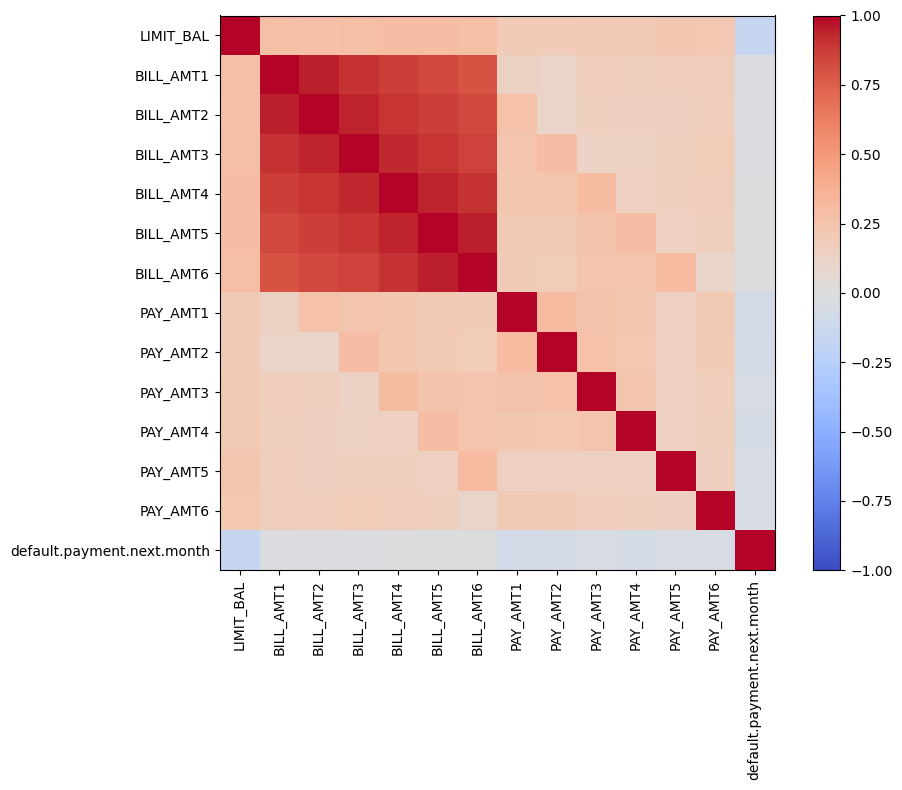

In [19]:
num = ["LIMIT_BAL"] + [f"BILL_AMT{i}" for i in range(1,7)] + [f"PAY_AMT{i}" for i in range(1,7)] + [TARGET]
plt.figure(figsize=(10,8))
plt.imshow(df[num].corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(); plt.xticks(range(len(num)), num, rotation=90)
plt.yticks(range(len(num)), num)
plt.tight_layout()
plt.savefig('../data/processed/correlation_num_features.png')
plt.show()

**Observation:** the six `BILL_AMT` columns are strongly correlated with each other
(a client's bill changes little month to month) — clear multicollinearity, which suggests
summary features (e.g. average bill, utilisation) could capture them without redundancy and
warrants care if using linear models. None of these numeric features correlate strongly with
the target on their own, so we expect non-linear models (tree ensembles) to help.

## 11. Credit limit vs default

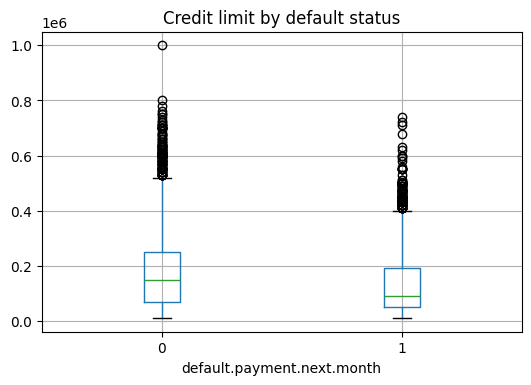

In [20]:
df.boxplot(column="LIMIT_BAL", by=TARGET, figsize=(6,4))
plt.title("Credit limit by default status")
plt.suptitle("")
plt.savefig('../data/processed/credit_limit_default.png')
plt.show()

**Observation:** defaulting clients tend to have **lower credit limits**, an
interpretable and useful signal — institutions extend smaller limits to riskier clients.

## Summary of findings

- **No missing data**; cleaning is limited to recoding undocumented EDUCATION/MARRIAGE
  codes into "other" (done in `load_data`).
- **Imbalanced target** (~22% default) → evaluate with Macro F1, not accuracy.
- **Repayment status dominates the feature screen**, led by `PAY_0`: its default rate
  jumps from ~13% to ~70% as recent payment delay increases, and influence fades for older
  months (PAY_2 > ... > PAY_6).
- Demographic and age effects are **weak but present**.
- `BILL_AMT` columns are **highly intercorrelated** → candidates for feature engineering.
- **Lower credit limits** are associated with higher default risk.

These insights guide the next stage: a leakage-safe pipeline, class-imbalance handling,
and Macro-F1-oriented threshold tuning in `train.py`.